#### Setup environment

In [2]:
from pathlib import Path
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
# Configure Chinese font for matplotlib
plt.rcParams['font.sans-serif'] = ['Noto Sans TC']
plt.rcParams['axes.unicode_minus'] = False  # Fix minus sign display

#### Import dataset

In [4]:
file_path = Path.cwd() / '..' / 'csv' / '1880-2020年均溫.csv'
df = pd.read_csv(file_path)
df.head()

,Decade,Change from 1880
0,1880,0.000
1,1890,0.020
2,1900,0.015
3,1910,-0.002
4,1920,0.099


#### EDA - plot temperature change

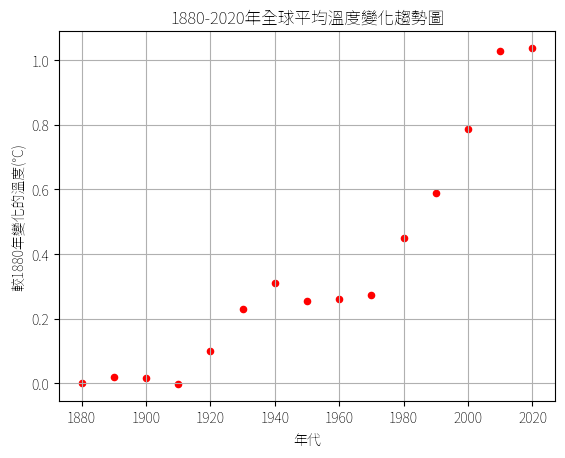

In [6]:
df.plot(kind='scatter', x = 'Decade', y = 'Change from 1880', color='red')
plt.title('1880-2020年全球平均溫度變化趨勢圖')
plt.xlabel('年代')
plt.ylabel('較1880年變化的溫度(°C)')
plt.grid()
plt.show()
# after 1970, temperature changes seems align with a linear function

#### Build regression model (1880 ~ 2020)

In [12]:
df_X = df[['Decade']]
df_y = df['Change from 1880']
lm = LinearRegression()
lm.fit(df_X, df_y)
print('1880~2020 回歸模型訓練完成')
print(f'迴歸係數: {lm.coef_[0]:.2f}, 截距: {lm.intercept_:.2f}')

1880~2020 回歸模型訓練完成
迴歸係數: 0.01, 截距: -13.99


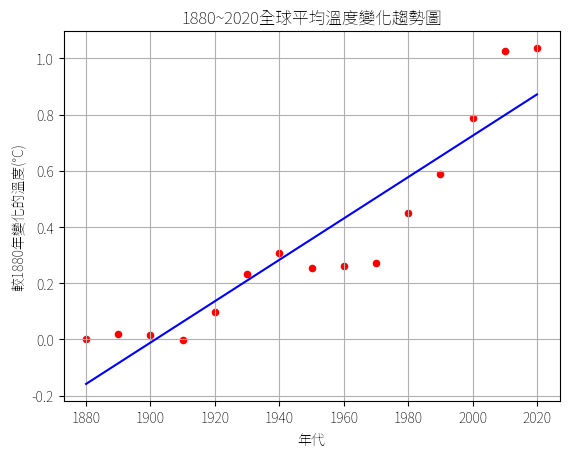

In [13]:
df.plot(kind='scatter', x = 'Decade', y = 'Change from 1880', color='red')
plt.title('1880~2020全球平均溫度變化趨勢圖')
plt.xlabel('年代')
plt.ylabel('較1880年變化的溫度(°C)')
plt.grid()
plt.plot(df['Decade'], lm.coef_ * df['Decade'] + lm.intercept_, 'b')
plt.show()

#### Build regression model (1970 ~ 2020) and predict 2030 ~ 2060 temperature changes

In [14]:
deleted_row_index = df[df['Decade'] < 1970].index
df.drop(deleted_row_index, inplace=True)
df.reset_index(drop=True, inplace=True)
df

,Decade,Change from 1880
0,1970,0.273
1,1980,0.450
2,1990,0.587
3,2000,0.787
4,2010,1.027
5,2020,1.037


In [15]:
df_X = df[['Decade']]
df_y = df['Change from 1880']
lm = LinearRegression()
lm.fit(df_X, df_y)
print('1970~2020 回歸模型訓練完成')
print(f'迴歸係數: {lm.coef_[0]:.2f}, 截距: {lm.intercept_:.2f}')

1970~2020 回歸模型訓練完成
迴歸係數: 0.02, 截距: -32.09


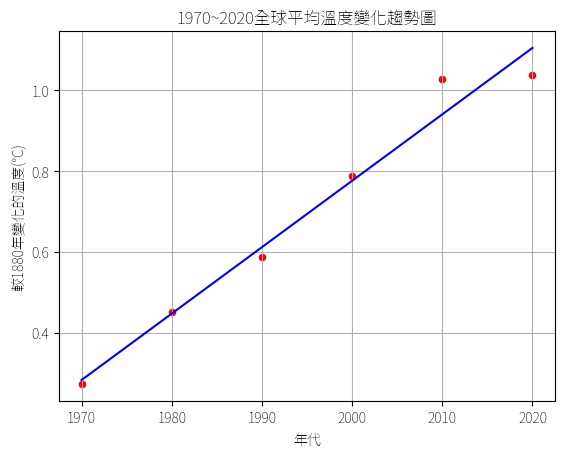

In [10]:
df.plot(kind='scatter', x = 'Decade', y = 'Change from 1880', color='red')
plt.title('1970~2020全球平均溫度變化趨勢圖')
plt.xlabel('年代')
plt.ylabel('較1880年變化的溫度(°C)')
plt.grid()
plt.plot(df['Decade'], lm.coef_ * df['Decade'] + lm.intercept_, 'b')
plt.show()

#### Predict temperature change 2030, 2040, 2050, 2060

In [16]:
# Create prediction DataFrame and display results
future_data = pd.DataFrame({
    'Decade': [2030, 2040, 2050, 2060]
})
future_data['Change from 1880'] = lm.predict(future_data[['Decade']])
future_data

,Decade,Change from 1880
0,2030,1.268600
1,2040,1.432914
2,2050,1.597229
3,2060,1.761543


# Backup

In [12]:
# merge dataframe df and future_data for complete view
complete_data = pd.concat([df, future_data], ignore_index=True)
complete_data

,Decade,Change from 1880
0,1970,0.273000
1,1980,0.450000
2,1990,0.587000
3,2000,0.787000
4,2010,1.027000
5,2020,1.037000
6,2030,1.268600
7,2040,1.432914
8,2050,1.597229
9,2060,1.761543


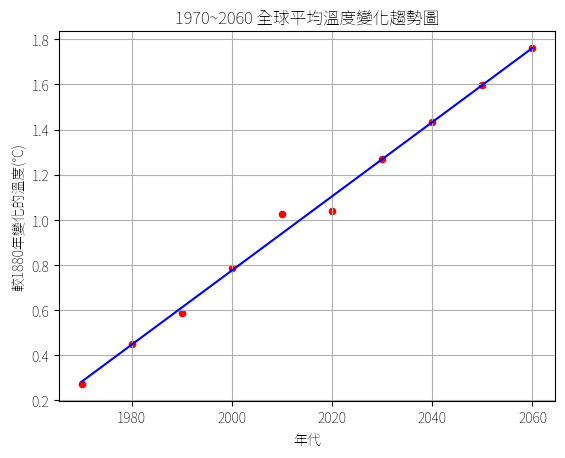

In [13]:
complete_data.plot(kind='scatter', x = 'Decade', y = 'Change from 1880', color='red')
plt.title('1970~2060 全球平均溫度變化趨勢圖')
plt.xlabel('年代')
plt.ylabel('較1880年變化的溫度(°C)')
plt.grid()
plt.plot(complete_data['Decade'], lm.coef_ * complete_data['Decade'] + lm.intercept_, 'b')
plt.show()